# OrientationJ Distribution (Python GST)

Faithful Python reproduction of **OrientationJ Distribution** on the 16 images of
[../orientationj-test-images](../orientationj-test-images): the histogram of the pixel orientations in
**180 bins of 1°** (bin centers −89.5° … +89.5°), with the plugin defaults —
cubic-spline gradient, σ = 1, and selection thresholds min-coherency = 0 % and
min-energy = 0 %.

**Only the pixels inside the mask of [../orientationj-test-images/masks](../orientationj-test-images/masks)
are counted** (nonzero = analyzed). The masks remove the flat background, which
otherwise piles up in a few bins — see the *degenerate-tensor* section at the end.

For every image, `results/distribution/` receives `<name>-distribution.csv` in the
exact format of the OJ-Distribution results table: a column `Orientation` with the
bin centers and a column `Slice1` with the counts (the plugin's column name).

The notebook also computes, per image:
- the **dominant orientation** (center of the fullest bin),
- the **axial circular mean** and the **axial order parameter R**
  (computed on doubled angles; R = 0 isotropic, R = 1 perfectly aligned),

saved to `distribution-statistics.csv`, and ends with the summary page
**`results/distribution/distribution-summary.md`**.

In [1]:
import datetime
import glob
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tifffile

import orientationj as oj

SIGMA = 1.0          # structure-tensor Gaussian window (OrientationJ default)
EPSILON = 0.001      # coherency regularisation (OrientationJ default)
MIN_COHERENCY = 0.0  # selection threshold in %, plugin default
MIN_ENERGY = 0.0     # selection threshold in %, plugin default
INPUT = os.path.join('..', 'orientationj-test-images')
MASKS = os.path.join(INPUT, 'masks')
OUTPUT = os.path.join('results', 'distribution')
os.makedirs(OUTPUT, exist_ok=True)

plt.rcParams.update({
    'figure.facecolor': 'white', 'font.size': 10, 'axes.titlesize': 10,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.edgecolor': '#cfcec6', 'grid.color': '#e8e8e4', 'grid.linewidth': 0.8,
    'text.color': '#3a3a37', 'axes.labelcolor': '#3a3a37',
    'xtick.color': '#6b6a63', 'ytick.color': '#6b6a63'})
ACCENT = '#4878a8'

In [2]:
paths = sorted(glob.glob(os.path.join(INPUT, '*.tif')))
images = {os.path.splitext(os.path.basename(p))[0]: oj.load(p) for p in paths}
for name, image in images.items():
    print(f'{name:42s} {image.shape}')
names = list(images.keys())
print(len(names), 'images')

masks = {name: tifffile.imread(os.path.join(MASKS, name + '.tif')) > 0
         for name in names}
for name in names:
    print(f'{name:42s} mask covers {100 * masks[name].mean():5.1f} % of the image')

cell_aemisegger                            (728, 728)
collagen                                   (512, 512)
dendrochronology                           (512, 512)
fibronectin_arafat_plos2025                (1024, 1024)
fibrous_tissues_fibero2024                 (2048, 2048)
fiji_directionality_montage                (1536, 1536)
nanofiber_fiji_diameterj                   (512, 512)
polymer_slice_quanfima2018                 (600, 600)
synthetic_chirp_1024                       (1024, 1024)
synthetic_filaments_512                    (512, 512)
synthetic_nematic_512                      (512, 512)
synthetic_noise_512                        (512, 512)
synthetic_rings_dither_512                 (512, 512)
synthetic_spiral_512                       (512, 512)
synthetic_wave_512                         (512, 512)
z_artificial_fibers                        (512, 683)
16 images
cell_aemisegger                            mask covers  25.8 % of the image
collagen                                  

In [3]:
def axial_stats(counts, angles):
    """Dominant bin, axial circular mean and order parameter R of a histogram."""
    theta2 = np.radians(2.0 * angles)
    total = counts.sum()
    c = (counts * np.cos(theta2)).sum() / total
    s = (counts * np.sin(theta2)).sum() / total
    return angles[np.argmax(counts)], 0.5 * np.degrees(np.arctan2(s, c)), np.hypot(c, s)


histos = {}
stats = []
for name, image in images.items():
    f = oj.analysis(image, sigma=SIGMA, epsilon=EPSILON)
    table = oj.distribution_table(f, MIN_COHERENCY, MIN_ENERGY, mask=masks[name])
    table.to_csv(os.path.join(OUTPUT, name + '-distribution.csv'), index=False)
    histo, angles, _ = oj.distribution(f, MIN_COHERENCY, MIN_ENERGY, mask=masks[name])
    histos[name] = histo
    dominant, mean, order = axial_stats(histo, angles)
    stats.append({'image': name, 'masked pixels': int(histo.sum()),
                  'dominant [deg]': dominant, 'axial mean [deg]': round(mean, 2),
                  'order parameter R': round(order, 4)})
    print(f'{name:42s} dominant {dominant:6.1f} deg   R = {order:.3f}')

stats = pd.DataFrame(stats)
stats.to_csv(os.path.join(OUTPUT, 'distribution-statistics.csv'), index=False)
stats

cell_aemisegger                            dominant   -5.5 deg   R = 0.615
collagen                                   dominant   48.5 deg   R = 0.111


dendrochronology                           dominant  -48.5 deg   R = 0.025


fibronectin_arafat_plos2025                dominant   45.5 deg   R = 0.371


fibrous_tissues_fibero2024                 dominant  -20.5 deg   R = 0.551


fiji_directionality_montage                dominant  -59.5 deg   R = 0.382
nanofiber_fiji_diameterj                   dominant  -45.5 deg   R = 0.244


...

synthetic_chirp_1024                       dominant    0.5 deg   R = 0.000
synthetic_filaments_512                    dominant  -89.5 deg   R = 0.083


synthetic_nematic_512                      dominant   17.5 deg   R = 0.127
synthetic_noise_512                        dominant  -58.5 deg   R = 0.007


synthetic_rings_dither_512                 dominant   44.5 deg   R = 0.000
synthetic_spiral_512                       dominant  -45.5 deg   R = 0.000


synthetic_wave_512                         dominant   60.5 deg   R = 0.994
z_artificial_fibers                        dominant  -41.5 deg   R = 0.088


,image,masked pixels,dominant [deg],axial mean [deg],order parameter R
0,cell_aemisegger,136565,-5.5,-7.05,0.6151
1,collagen,105334,48.5,57.12,0.1110
2,dendrochronology,121551,-48.5,-72.82,0.0254
3,fibronectin_arafat_plos2025,536350,45.5,41.23,0.3708
4,fibrous_tissues_fibero2024,222208,-20.5,-11.28,0.5508
5,fiji_directionality_montage,1812161,-59.5,-51.15,0.3821
6,nanofiber_fiji_diameterj,103600,-45.5,-25.19,0.2442
7,polymer_slice_quanfima2018,52135,-89.5,-85.24,0.6278
8,synthetic_chirp_1024,632032,0.5,72.62,0.0000
9,synthetic_filaments_512,125383,-89.5,-55.81,0.0832


## Distributions of orientation (inside the mask)

One histogram per image. A flat histogram means an isotropic image, a sharp peak a
strongly aligned one.

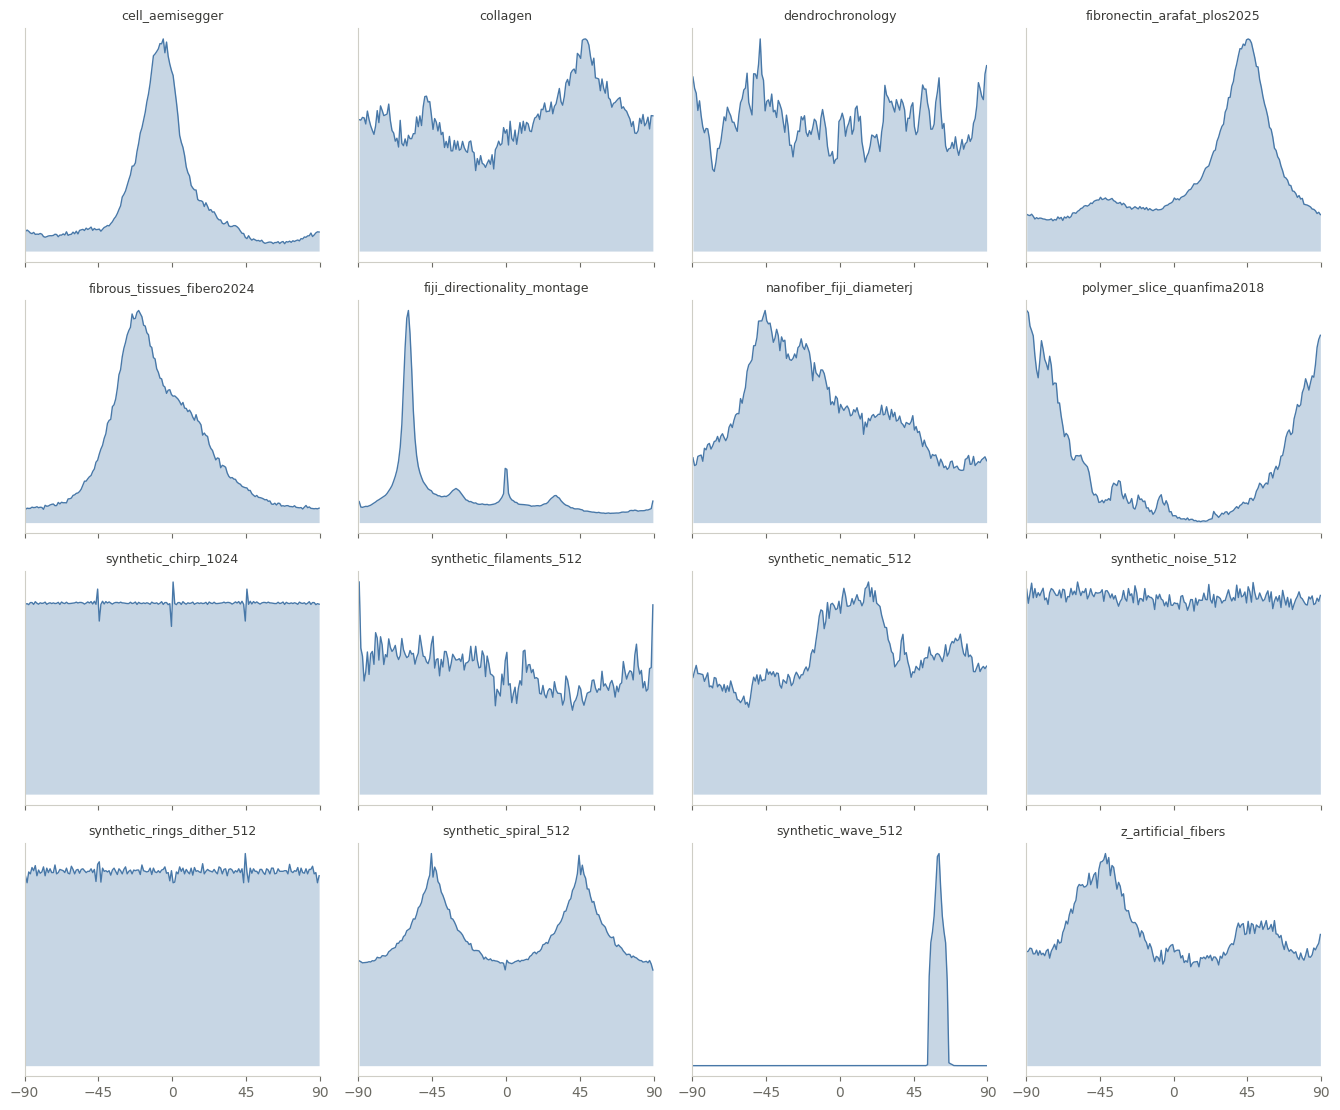

In [4]:
rows = -(-len(names) // 4)
fig, axes = plt.subplots(rows, 4, figsize=(13.5, 2.8 * rows), sharex=True)
for ax in axes.flat:
    ax.axis('off')
for ax, name in zip(axes.flat, names):
    ax.axis('on')
    ax.fill_between(angles, histos[name], color=ACCENT, alpha=0.3, linewidth=0)
    ax.plot(angles, histos[name], color=ACCENT, linewidth=1.0)
    ax.set_title(name, fontsize=9)
    ax.set_xlim(-90, 90)
    ax.set_xticks(range(-90, 91, 45))
    ax.set_yticks([])
fig.tight_layout()
plt.show()

## Degenerate tensors: flat areas spike at exactly 0°, ±45° and ±90°

Counted over **all** pixels, `synthetic_chirp_1024` shows sharp spikes at 0° and
±90°. In its flat apodised corners the image is numerically constant, so the
structure tensor is degenerate — dominated by the float32 quantization of the
image, its entries satisfy exactly `Jxy = 0` or `Jxx = Jyy`, and the half-angle
formula θ = ½ atan2(2Jxy, Jyy − Jxx) returns *exactly* 0° (atan2(0, ≥0)),
±90° (atan2(±0, <0)) or ±45° (Jyy = Jxx). Whole background regions collapse into
those few bins; natural images never show this because sensor noise gives every
pixel a random orientation.

`synthetic_rings_dither_512` is generated **with an invisible dither**
(σ = 10⁻⁴ of the intensity range) precisely to avoid this: the noise breaks the
flat plateaus and the exact central symmetry of the pattern, so its histogram
stays clean even when every pixel is counted. The mask — used everywhere in this
notebook — removes the background contribution altogether; the plugin's
min-energy / min-coherency thresholds are the equivalent remedy in ImageJ.

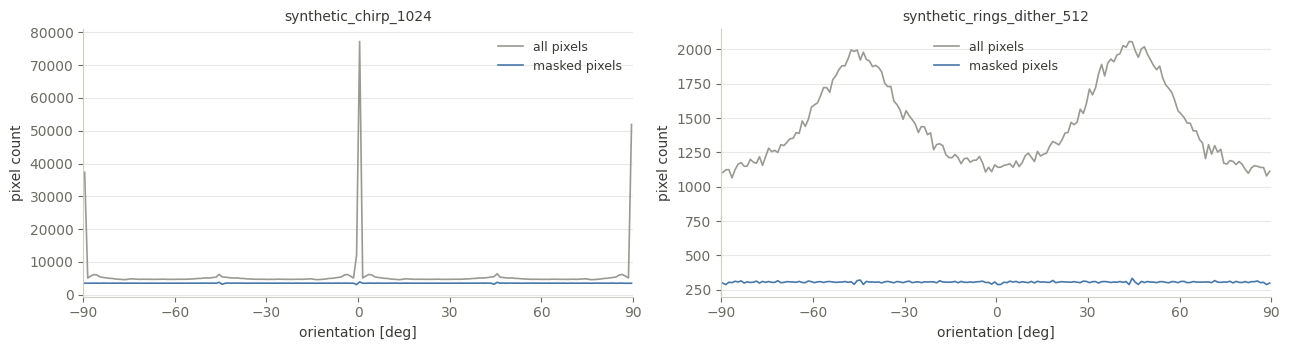

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 3.6))
for ax, name in zip(axes, ('synthetic_chirp_1024', 'synthetic_rings_dither_512')):
    f = oj.analysis(images[name], sigma=SIGMA, epsilon=EPSILON)
    histo_all, angles, _ = oj.distribution(f, MIN_COHERENCY, MIN_ENERGY)
    ax.plot(angles, histo_all, color='#9a9a94', linewidth=1.2, label='all pixels')
    ax.plot(angles, histos[name], color=ACCENT, linewidth=1.2, label='masked pixels')
    ax.set_xlim(-90, 90)
    ax.set_xticks(range(-90, 91, 30))
    ax.set_xlabel('orientation [deg]')
    ax.set_ylabel('pixel count')
    ax.grid(True, axis='y')
    ax.set_axisbelow(True)
    ax.set_title(name, fontsize=10)
    ax.legend(frameon=False, fontsize=9)
fig.tight_layout()
plt.show()

## Summary page

Statistics table and one figure per image (input with the mask outline + histogram).
Written to `results/distribution/distribution-summary.md`
(figures in `results/distribution/figures/`).

In [6]:
FIGURES = os.path.join(OUTPUT, 'figures')
os.makedirs(FIGURES, exist_ok=True)

lines = [
    '# OrientationJ Distribution — Python GST',
    '',
    '*Generated on ' + datetime.date.today().isoformat()
        + ' by [distribution.ipynb](../../distribution.ipynb).*',
    '',
    '- Distribution of the pixel orientations, 180 bins of 1 degree',
    '- Gradient: cubic spline (plugin default), structure-tensor window sigma = '
        + str(SIGMA),
    '- Selection: only pixels inside the mask (orientationj-test-images/masks, outlined in red),',
    '  min-coherency = ' + str(MIN_COHERENCY) + ' %, min-energy = ' + str(MIN_ENERGY) + ' %',
    '- Per image: `<name>-distribution.csv` in the OJ-Distribution table format',
    '',
    '## Statistics (masked pixels only)',
    '',
    '| ' + ' | '.join(stats.columns) + ' |',
    '|' + '---|' * len(stats.columns)]
for row in stats.itertuples(index=False):
    lines.append('| ' + ' | '.join(str(value) for value in row) + ' |')
lines.append('')

for name in names:
    histo = histos[name]
    dominant, mean, order = axial_stats(histo, angles)

    fig = plt.figure(figsize=(11.7, 4.6))
    gs = fig.add_gridspec(1, 2, width_ratios=[1.1, 2.1], wspace=0.18,
                          left=0.04, right=0.96, top=0.88, bottom=0.14)
    ax0 = fig.add_subplot(gs[0])
    ax0.imshow(images[name], cmap='gray')
    ax0.contour(masks[name], levels=[0.5], colors='#b0533a', linewidths=0.6,
                alpha=0.4)
    ax0.axis('off')
    ax1 = fig.add_subplot(gs[1])
    ax1.fill_between(angles, histo, color=ACCENT, alpha=0.3, linewidth=0)
    ax1.plot(angles, histo, color=ACCENT, linewidth=1.2)
    ax1.axvline(dominant, color='#b0533a', linewidth=1.0, linestyle='--')
    ax1.set_xlim(-90, 90)
    ax1.set_xticks(range(-90, 91, 30))
    ax1.set_xlabel('orientation [deg]')
    ax1.set_ylabel('pixel count')
    ax1.grid(True, axis='y')
    ax1.set_axisbelow(True)
    fig.savefig(os.path.join(FIGURES, name + '.png'), dpi=130, bbox_inches='tight')
    plt.close(fig)

    lines += ['## ' + name,
              '',
              'dominant ' + format(dominant, '.1f') + ' deg — axial mean '
                  + format(mean, '.1f') + ' deg — R = ' + format(order, '.3f'),
              '', '![' + name + '](figures/' + name + '.png)', '']

page_path = os.path.join(OUTPUT, 'distribution-summary.md')
open(page_path, 'w').write('\n'.join(lines))
print('written', page_path)

written results/distribution/distribution-summary.md
